# PandaX-4T accidental-coincidence (AC) template

Builds the AC background template in the analysis space (cs1, log10(cs2_b/cs1)) from the digitized 1$\sigma$/2$\sigma$ AC contours, for Run0 and Run1.

**Why not the `ac_template_contour.ipynb` (XENONnT) method.** That method casts rays from a single peak and fits a smooth `exp(-a r^2 - b r)` density -- it assumes a *unimodal, star-convex, closed* contour. The PandaX AC contours are (i) **open arcs** anchored to the left ROI edge cs1=2 (straight auto-closure gives a wrong diagonal that can even cut off part of the 1$\sigma$ region), and (ii) **bimodal** for Run1 (a second 1$\sigma$ lobe in the upper-left corner). So we use a robust **contour-band** model instead.

**Method.** Close each arc along the left edge (cs1=2); build inside masks with `matplotlib.path`. Assign a piecewise-constant density by band so the enclosed probabilities match the contour levels: 1$\sigma$ -> 0.68, 2$\sigma$ -> 0.95 (the convention used by the XENONnT AC notebook), with the 5% tail spread over the rest of the ROI. Run1's 1$\sigma$ region is the **union** of its two lobes; the 2$\sigma$ region is forced to contain the 1$\sigma$. Integrate onto the analysis binning and normalize. The density level sets are the input contours by construction, so the model reproduces them up to the (coarse) analysis binning.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from multihist import Histdd
import inference_interface
import diamx

DATA = os.path.join(os.path.dirname(diamx.__file__), 'data')
load = lambda n: np.loadtxt(os.path.join(DATA, n), delimiter=',')

# analysis binning -- must match the experiment config roi
CS1_EDGES = np.linspace(2, 135, 28)
Y_EDGES   = np.linspace(0.5, 3.5, 31)
X_MIN = CS1_EDGES[0]                     # left ROI edge the arcs are anchored to
HIST_NAME = 'cs1-logcs2_s1'

# enclosed-probability convention for the sigma contours
P1, P2 = 0.68, 0.95                      # mass inside 1sigma, 2sigma
SUB = 20                                 # fine sub-sampling per analysis bin

# AC contours per run: 1sigma lobes (list) and the 2sigma contour
CONTOURS = {
    'run0': dict(one=['pandax4t_run0_ac_1sigma.csv'], two='pandax4t_run0_ac_2sigma.csv'),
    'run1': dict(one=['pandax4t_run1_ac_1sigma_0.csv', 'pandax4t_run1_ac_1sigma_1.csv'],
                 two='pandax4t_run1_ac_2sigma.csv'),
}

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform


/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using aptext package from https://github.com/XENONnT/applefiles


/home/mhliu/Documents/appletree/appletree/__init__.py:54: UserWarning: You are running appletree on CPU, which usually results in low performance.
  warn(warning)


## Build the band-density template

In [2]:
def left_edge_closed(pts):
    # close the open arc by routing along the left ROI edge cs1=X_MIN
    pts = np.asarray(pts)
    return np.vstack([pts, [X_MIN, pts[-1, 1]], [X_MIN, pts[0, 1]]])

def inside_mask(csv_names, FX, FY):
    # union of the (left-edge-closed) contours' interiors, on the fine grid
    pq = np.column_stack([FX.ravel(), FY.ravel()])
    m = np.zeros(FX.size, bool)
    for nm in csv_names:
        m |= Path(left_edge_closed(load(nm))).contains_points(pq)
    return m.reshape(FX.shape)

def build_ac_template(run):
    c = CONTOURS[run]
    # fine grid over the ROI (integer multiple of the analysis bins)
    nfx, nfy = (len(CS1_EDGES) - 1) * SUB, (len(Y_EDGES) - 1) * SUB
    fx = np.linspace(CS1_EDGES[0], CS1_EDGES[-1], nfx + 1); fx = 0.5 * (fx[:-1] + fx[1:])
    fy = np.linspace(Y_EDGES[0], Y_EDGES[-1], nfy + 1);   fy = 0.5 * (fy[:-1] + fy[1:])
    FX, FY = np.meshgrid(fx, fy, indexing='ij')
    cell = (CS1_EDGES[-1] - CS1_EDGES[0]) / nfx * (Y_EDGES[-1] - Y_EDGES[0]) / nfy
    m1 = inside_mask(c['one'], FX, FY)
    m2 = inside_mask([c['two']], FX, FY) | m1     # 2sigma must contain 1sigma
    band = m2 & ~m1
    tail = ~m2
    A1, Ab, At = m1.sum() * cell, band.sum() * cell, tail.sum() * cell
    rho = np.zeros(FX.shape)
    rho[m1]   = P1 / A1                            # 1sigma holds 0.68
    rho[band] = (P2 - P1) / Ab                     # 1->2 sigma band holds 0.27
    rho[tail] = (1 - P2) / At                      # tail holds 0.05 over the ROI
    # integrate onto the analysis bins (block-average the density)
    hist = rho.reshape(len(CS1_EDGES) - 1, SUB, len(Y_EDGES) - 1, SUB).mean(axis=(1, 3))
    hist /= hist.sum()
    # save as an inference_interface template (cs1, logcs2_s1)
    cx = 0.5 * (CS1_EDGES[:-1] + CS1_EDGES[1:]); cy = 0.5 * (Y_EDGES[:-1] + Y_EDGES[1:])
    CX, CY = np.meshgrid(cx, cy, indexing='ij')
    mh = Histdd(CX.ravel(), CY.ravel(), bins=[CS1_EDGES, Y_EDGES],
                weights=hist.ravel(), axis_names=['cs1', 'logcs2_s1'])
    out = os.path.join(DATA, f'pandax4t_{run}_ac_template.h5')
    inference_interface.multihist_to_template([mh], out, [HIST_NAME])
    print(f'{run}: areas 1s={A1:.2f} band={Ab:.2f} tail={At:.0f}; wrote {os.path.basename(out)}')
    return hist, (m1, m2)

res = {run: build_ac_template(run) for run in ('run0', 'run1')}

run0: areas 1s=2.17 band=11.29 tail=386; wrote pandax4t_run0_ac_template.h5
run1: areas 1s=2.23 band=7.43 tail=389; wrote pandax4t_run1_ac_template.h5


## Validation: template heatmap vs input contours (and derived 68/95 levels)
The coarse-binned template is shown with the digitized input contours overlaid, plus the 68%/95% enclosed-probability contours recomputed from the template. They should track the inputs up to the analysis binning (cs1 has only ~3 bins over the AC region).

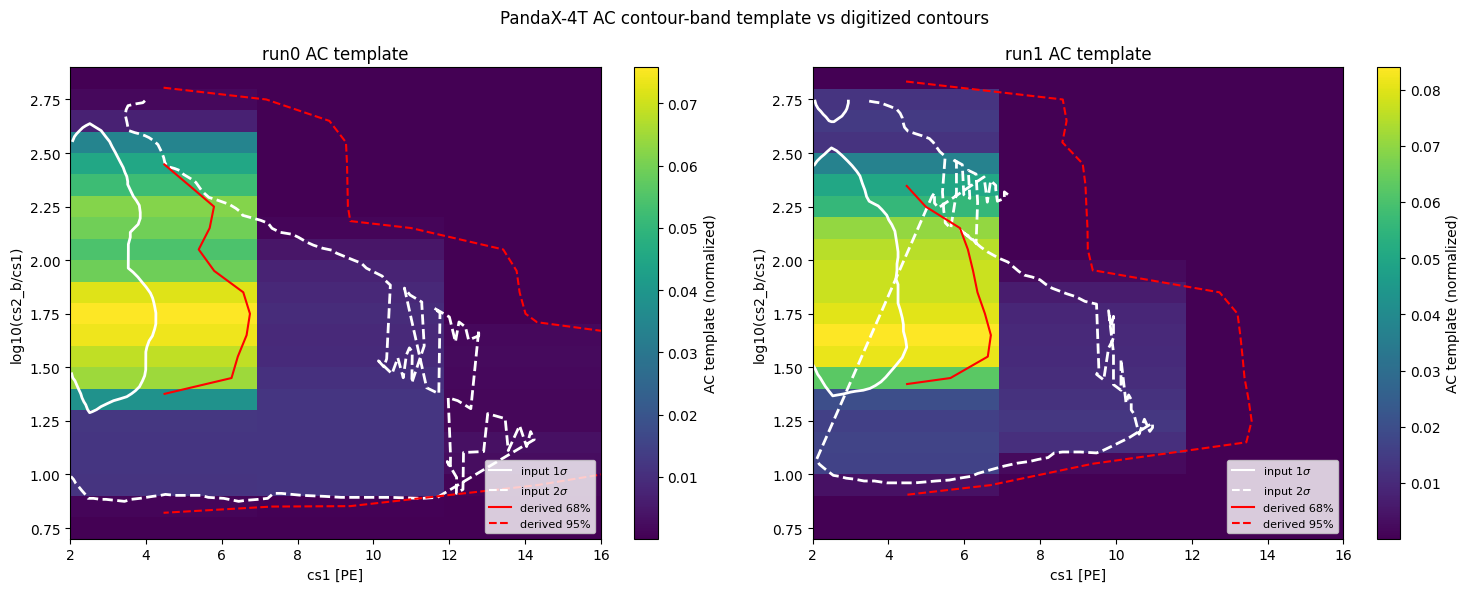

In [3]:
def enclosed_level(hist, frac):
    s = np.sort(hist.ravel())[::-1]; csum = np.cumsum(s) / s.sum()
    return s[np.searchsorted(csum, frac)]

cx = 0.5 * (CS1_EDGES[:-1] + CS1_EDGES[1:]); cy = 0.5 * (Y_EDGES[:-1] + Y_EDGES[1:])
CX, CY = np.meshgrid(cx, cy, indexing='ij')
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for j, run in enumerate(['run0', 'run1']):
    hist = res[run][0]
    pm = ax[j].pcolormesh(CS1_EDGES, Y_EDGES, hist.T, cmap='viridis', shading='flat')
    fig.colorbar(pm, ax=ax[j], label='AC template (normalized)')
    for nm, sty in zip(CONTOURS[run]['one'], ['w-', 'w-']):
        d = load(nm); ax[j].plot(d[:, 0], d[:, 1], sty, lw=2)
    d = load(CONTOURS[run]['two']); ax[j].plot(d[:, 0], d[:, 1], 'w--', lw=2)
    ax[j].contour(CX, CY, hist, levels=[enclosed_level(hist, P2), enclosed_level(hist, P1)],
                  colors='red', linestyles=['--', '-'], linewidths=1.5)
    ax[j].plot([], [], 'w-', label='input 1$\\sigma$'); ax[j].plot([], [], 'w--', label='input 2$\\sigma$')
    ax[j].plot([], [], 'r-', label='derived 68%'); ax[j].plot([], [], 'r--', label='derived 95%')
    ax[j].set(title=f'{run} AC template', xlabel='cs1 [PE]', ylabel='log10(cs2_b/cs1)',
              xlim=(2, 16), ylim=(0.7, 2.9)); ax[j].legend(loc='lower right', fontsize=8)
fig.suptitle('PandaX-4T AC contour-band template vs digitized contours')
fig.tight_layout(); plt.show()